In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import precision_score, recall_score, roc_auc_score

%matplotlib inline
import matplotlib.pyplot as plt

## 1. Analysis and Processing of Attributes

We start by loading the raw dataset and inspecting each attribute's type and value range.

In [2]:
df_raw = pd.read_csv("./data/Covid19.csv", index_col=0)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (387596, 19)


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,DEATH,CLASIFFICATION_FINAL
0,0,1,Female,1,1,65,0,0,0,0,0,1,0,0,0,0,0,1,3
2,0,1,Male,0,0,55,0,1,0,0,0,0,0,0,0,0,0,1,3
4,0,1,Male,1,0,68,0,1,0,0,0,1,0,0,0,0,0,1,3
5,0,1,Female,0,1,40,0,0,0,0,0,0,0,0,0,0,0,0,3
6,0,1,Female,1,0,64,0,0,0,0,0,0,0,0,0,0,0,0,3


In [3]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.DataFrame'>
Index: 387596 entries, 0 to 1021520
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   USMER                 387596 non-null  int64
 1   MEDICAL_UNIT          387596 non-null  int64
 2   SEX                   387596 non-null  str  
 3   PATIENT_TYPE          387596 non-null  int64
 4   PNEUMONIA             387596 non-null  int64
 5   AGE                   387596 non-null  int64
 6   PREGNANT              387596 non-null  int64
 7   DIABETES              387596 non-null  int64
 8   COPD                  387596 non-null  int64
 9   ASTHMA                387596 non-null  int64
 10  INMSUPR               387596 non-null  int64
 11  HIPERTENSION          387596 non-null  int64
 12  OTHER_DISEASE         387596 non-null  int64
 13  CARDIOVASCULAR        387596 non-null  int64
 14  OBESITY               387596 non-null  int64
 15  RENAL_CHRONIC         387596 non-null  int64
 16 

range of values for each attribute:

In [4]:
df_raw.describe()

,USMER,MEDICAL_UNIT,PATIENT_TYPE,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,DEATH,CLASIFFICATION_FINAL
count,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000,387596.000000
mean,0.375889,8.677659,0.717087,0.218434,45.156570,0.007080,0.158794,0.015655,0.026618,0.012175,0.196246,0.025638,0.021675,0.185990,0.020333,0.073515,0.137571,2.951922
std,0.484352,3.771074,0.450415,0.413184,16.458651,0.083842,0.365485,0.124139,0.160964,0.109667,0.397157,0.158052,0.145619,0.389099,0.141137,0.260980,0.344450,0.298662
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,4.000000,0.000000,0.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.000000,12.000000,1.000000,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,1.000000,12.000000,1.000000,0.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.000000,13.000000,1.000000,1.000000,120.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [5]:
for col in df_raw.columns:
    uvals = sorted(df_raw[col].unique())
    print(f"{col:25s}  n_unique={len(uvals):4d}  values={uvals[:10]}")

USMER                      n_unique=   2  values=[np.int64(0), np.int64(1)]
MEDICAL_UNIT               n_unique=  13  values=[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
SEX                        n_unique=   2  values=['Female', 'Male']
PATIENT_TYPE               n_unique=   2  values=[np.int64(0), np.int64(1)]
PNEUMONIA                  n_unique=   2  values=[np.int64(0), np.int64(1)]
AGE                        n_unique= 108  values=[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
PREGNANT                   n_unique=   2  values=[np.int64(0), np.int64(1)]
DIABETES                   n_unique=   2  values=[np.int64(0), np.int64(1)]
COPD                       n_unique=   2  values=[np.int64(0), np.int64(1)]
ASTHMA                     n_unique=   2  values=[np.int64(0), np.int64(1)]
INMSUPR                    n_unique=  

we see that AGE and classification_final the only feature that are not binary. we will standardize them in preprocessing. We will split by MEDICAL_UNIT later, so we will have 13 groups

In [6]:
# SEX value distribution before encoding
print(df_raw["SEX"].value_counts())
print()

# CLASIFFICATION_FINAL value distribution
print(df_raw["CLASIFFICATION_FINAL"].value_counts().sort_index())

# Overall class distribution
print("\nDEATH distribution:")
print(df_raw["DEATH"].value_counts())
print(f"Class imbalance ratio: {df_raw['DEATH'].value_counts()[0] / df_raw['DEATH'].value_counts()[1]:.1f}:1")

SEX
Male      207594
Female    180002
Name: count, dtype: int64

CLASIFFICATION_FINAL
1      8417
2      1801
3    377378
Name: count, dtype: int64

DEATH distribution:
DEATH
0    334274
1     53322
Name: count, dtype: int64
Class imbalance ratio: 6.3:1


### Attribute encoding

| Attribute | Type | Encoding |
|---|---|---|
| USMER | Binary (0/1) | Already numeric, no change |
| MEDICAL_UNIT | Categorical (13 units) | Used only for partitioning, dropped from features |
| SEX | Nominal (Female/Male) | Female→0, Male→1 |
| PATIENT_TYPE | Binary (0/1) | Already numeric, no change |
| PNEUMONIA | Binary (0/1) | Already numeric, no change |
| AGE | Numerical | standardize with StandardScaler |
| PREGNANT | Binary (0/1) | Already numeric, no change |
| DIABETES | Binary (0/1) | Already numeric, no change |
| COPD | Binary (0/1) | Already numeric, no change |
| ASTHMA | Binary (0/1) | Already numeric, no change |
| INMSUPR | Binary (0/1) | Already numeric, no change |
| HIPERTENSION | Binary (0/1) | Already numeric, no change |
| OTHER_DISEASE | Binary (0/1) | Already numeric, no change |
| CARDIOVASCULAR | Binary (0/1) | Already numeric, no change |
| OBESITY | Binary (0/1) | Already numeric, no change |
| RENAL_CHRONIC | Binary (0/1) | Already numeric, no change |
| TOBACCO | Binary (0/1) | Already numeric, no change |
| CLASIFFICATION_FINAL | Ordinal (1, 2, 3) | Encode as 0, 0.5, 1  |
| **DEATH** | **Binary (0/1)** | **Target class — not a feature** |




## 2. Heterogeneity Analysis

we now analyze the class distribution of each unit

In [7]:
# Records per medical unit
unit_counts = df_raw.groupby("MEDICAL_UNIT").size().rename("total")

# Class distribution per unit
unit_death = df_raw.groupby("MEDICAL_UNIT")["DEATH"].agg(
    death_0=lambda x: (x == 0).sum(),
    death_1=lambda x: (x == 1).sum()
)
unit_death["pct_death"] = (unit_death["death_1"] / (unit_death["death_0"] + unit_death["death_1"]) * 100).round(2)

heterogeneity = pd.concat([unit_counts, unit_death], axis=1)
heterogeneity

,total,death_0,death_1,pct_death
MEDICAL_UNIT,,,,
0,12,12,0,0.00
1,40,37,3,7.50
3,8581,7439,1142,13.31
4,126409,98982,27427,21.70
5,2847,2432,415,14.58
6,17358,13460,3898,22.46
7,409,383,26,6.36
8,4931,3992,939,19.04
9,14017,13156,861,6.14


we see that the numbers vary a lot across the 13 medical units. to better see how much they differ, we plot this data: 

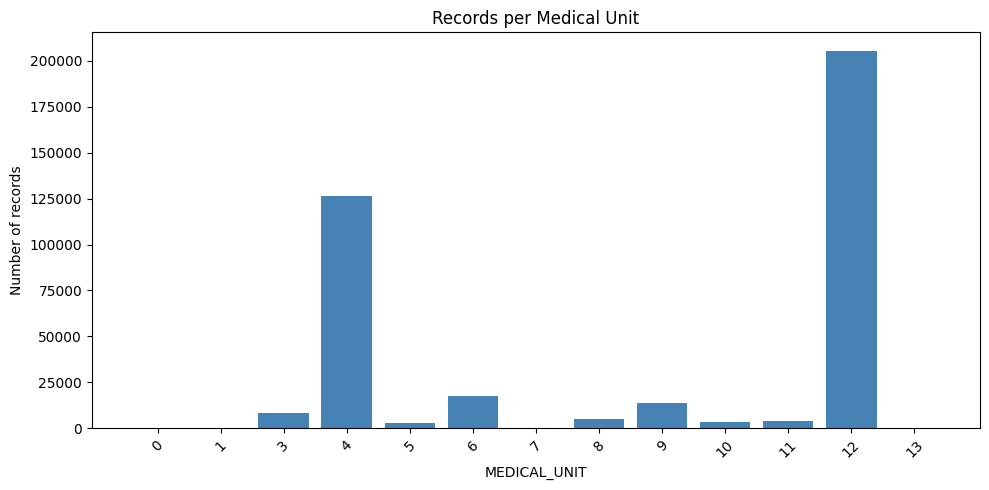

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(heterogeneity.index.astype(str), heterogeneity["total"], color="steelblue")
plt.title("Records per Medical Unit")
plt.xlabel("MEDICAL_UNIT")
plt.ylabel("Number of records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Unit 4 and 12 dominate the number of samples, Unit 12 alone makes up the majority of the total data. 

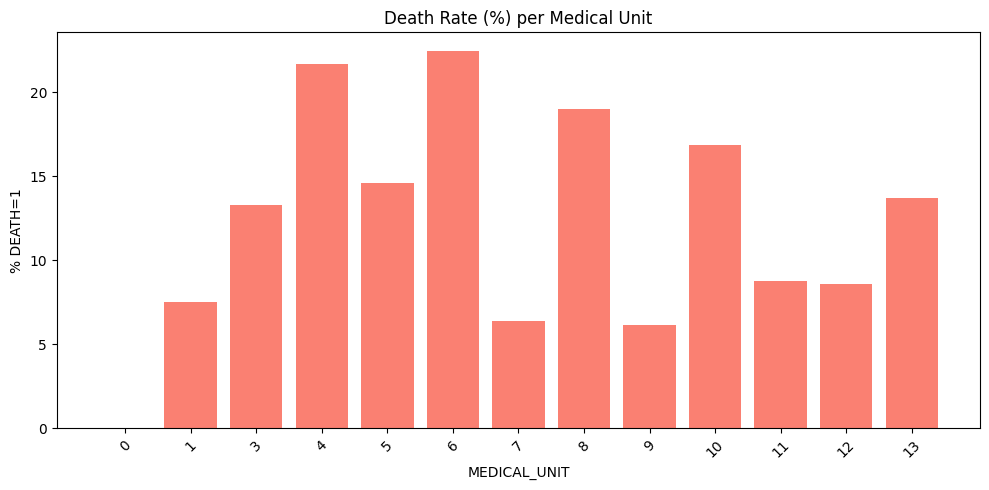

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(heterogeneity.index.astype(str), heterogeneity["pct_death"], color="salmon")
plt.title("Death Rate (%) per Medical Unit")
plt.xlabel("MEDICAL_UNIT")
plt.ylabel("% DEATH=1")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We observe that the death rate has a large variance across the medical units. Unit 0 doesn't have a single death case, we have to think about a way to handle this, since it will not be beneficial in federated learning if it provides updates that did didnt learn on even a single DEATH=1 example.

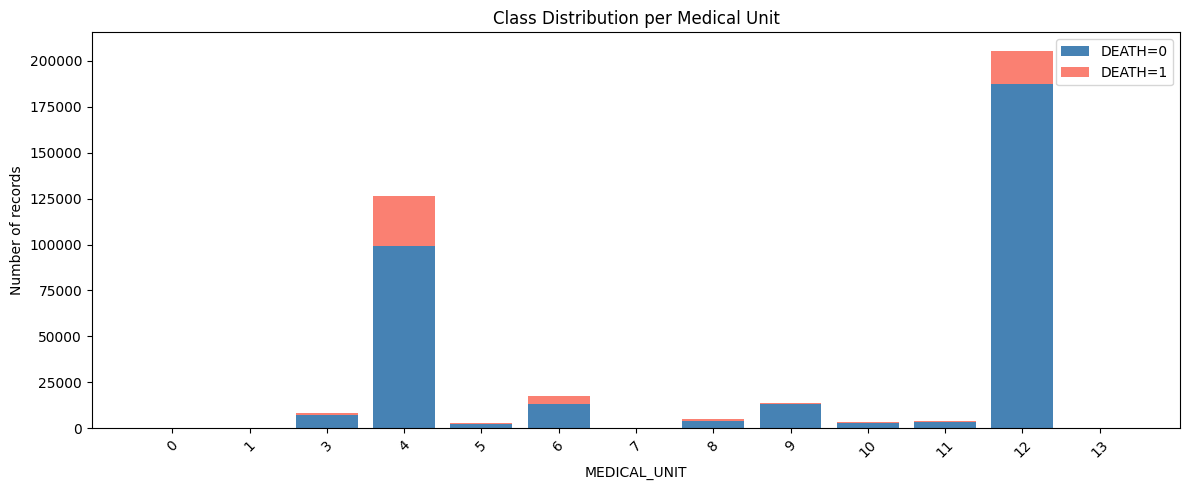

In [10]:

fig, ax = plt.subplots(figsize=(12, 5))
units = heterogeneity.index.astype(str)
ax.bar(units, heterogeneity["death_0"], label="DEATH=0", color="steelblue")
ax.bar(units, heterogeneity["death_1"], bottom=heterogeneity["death_0"], label="DEATH=1", color="salmon")
ax.set_title("Class Distribution per Medical Unit")
ax.set_xlabel("MEDICAL_UNIT")
ax.set_ylabel("Number of records")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


Overall we see that the splitting by medical unit results in very heterogenous data (number of train samples, class proportions)

## Model Architecture

In [11]:
def Net():
    model = nn.Sequential()
    model.add_module('hidden0', nn.Linear(17, 60))
    model.add_module('activation0', nn.ReLU())
    model.add_module('dr0', nn.Dropout(0.3))
    model.add_module('output', nn.Linear(60, 1))
    model.add_module('sigmoid', nn.Sigmoid())
    return model

## StepByStep Training Helper

In [12]:
class StepByStep(object):
    def __init__(self, model, loss_fn=None, optimizer=None):
        # Here we define the attributes of our class
        # We start by storing the arguments as attributes
        # to use later
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # Let's send the model to the specified device right away
        self.model.to(self.device)

        # These attributes are defined here, but since they are
        # not available at the moment of creation, we keep them None
        self.train_loader = None
        self.val_loader = None

        # These attributes are going to be computed internally
        self.losses = []
        self.val_losses = []
        self.accuracies = []
        self.total_epochs = 0

        # Creates the train_step function for our model,
        # loss function and optimizer
        # Note: there are NO ARGS there! It makes use of the class
        # attributes directly
        self.train_step_fn = self._make_train_step_fn()
        # Creates the val_step function for our model and loss
        self.val_step_fn = self._make_val_step_fn()

    def set_loaders(self, train_loader, val_loader=None):
        # This method allows the user to define which train_loader
        # (and val_loader, optionally) to use
        # Both loaders are then assigned to attributes of the class
        # So they can be referred to later
        self.train_loader = train_loader
        self.val_loader = val_loader

    def set_valloader(self, val_loader):
        self.val_loader = val_loader

    def _make_train_step_fn(self):
        # This method does not need ARGS... it can use directly
        # the attributes: self.model, self.loss_fn and self.optimizer
        # Builds function that performs a step in the train loop
        def perform_train_step_fn(x, y):
            # Sets model to TRAIN mode
            self.model.train()

            # Step 1 - Computes model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # Step 3 - Computes gradients for "b" and "w" parameters
            loss.backward()
            # Step 4 - Updates parameters using gradients and the
            # learning rate
            self.optimizer.step()
            self.optimizer.zero_grad()

            # Returns the loss
            return loss.item()

        # Returns the function that will be called inside the train loop
        return perform_train_step_fn

    def _make_val_step_fn(self):
        # Builds function that performs a step in the validation loop
        def perform_val_step_fn(x, y):
            # Sets model to EVAL mode
            self.model.eval()

            # Step 1 - Computes model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # There is no need to compute Steps 3 and 4,
            # since we don't update parameters during evaluation
            return loss.item()

        return perform_val_step_fn

    def _mini_batch(self, validation=False):
        # The mini-batch can be used with both loaders
        # The argument `validation` defines which loader and
        # corresponding step function are going to be used
        if validation:
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        else:
            data_loader = self.train_loader
            step_fn = self.train_step_fn

        if data_loader is None:
            return None

        # Once the data loader and step function are set, this is the
        # same mini-batch loop we had before
        mini_batch_losses = []
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss = step_fn(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)

        loss = np.mean(mini_batch_losses)
        return loss

    def set_seed(self, seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.manual_seed(seed)
        np.random.seed(seed)

    def train(self, n_epochs, seed=42, print_every=10):
        # To ensure reproducibility of the training process
        self.set_seed(seed)

        for epoch in range(n_epochs):
            # Keeps track of the number of epochs
            # by updating the corresponding attribute
            self.total_epochs += 1

            # inner loop
            # Performs training using mini-batches
            loss = self._mini_batch(validation=False)
            self.losses.append(loss)

            # VALIDATION
            # no gradients in validation!
            with torch.no_grad():
                # Performs evaluation using mini-batches
                val_loss = self._mini_batch(validation=True)
                self.val_losses.append(val_loss)

            if (epoch + 1) % print_every == 0 or epoch == 0:
                print(f"Epoch {self.total_epochs:4d}/{n_epochs}  train_loss={loss:.4f}  val_loss={val_loss:.4f}")

    def load_state_dict(self, server_state_dict):
        # Restore state for model and optimizer
        self.model.load_state_dict(server_state_dict)
        self.model.train() # always use TRAIN for resuming training

    def predict(self, x):
        # Set it to evaluation mode for predictions
        self.model.eval()
        # Take a Numpy input and make it a float tensor
        x_tensor = torch.as_tensor(x).float()
        # Send input to device and use model for prediction
        y_hat_tensor = self.model(x_tensor.to(self.device))
        # Set it back to train mode
        self.model.train()
        # Detach it, bring it to CPU and back to Numpy
        return y_hat_tensor.detach().cpu().numpy()


## Train & Test Functions

In [13]:
def train(model, trainloader, testloader, epochs, lr, device):
    model.to(device)
    loss_fn = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    sbs = StepByStep(model, loss_fn, optimizer)
    sbs.set_loaders(trainloader, testloader)
    sbs.train(epochs)

    avg_train_loss = sum(sbs.losses) / len(sbs.losses)
    return avg_train_loss


def test(model, testloader, device):
    model.to(device)
    sbs = StepByStep(model)
    loss_fn = nn.BCELoss()

    loss_sum = 0
    all_probs = []
    all_preds = []
    all_labels = []

    for x_data, y_data in testloader:
        probs = torch.as_tensor(sbs.predict(x_data)).float()
        loss_sum += loss_fn(probs, y_data).item()
        all_probs.append(probs.detach().cpu())
        all_preds.append(torch.round(probs).detach().cpu())
        all_labels.append(y_data.detach().cpu())

    all_probs = torch.cat(all_probs).numpy().flatten()
    all_preds = torch.cat(all_preds).numpy().flatten()
    all_labels = torch.cat(all_labels).numpy().flatten()

    loss = loss_sum / len(testloader)
    accuracy = (all_preds == all_labels).mean()
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return loss, accuracy, precision, recall, auc

## preprocessing and Data Loading

we transform SEX to a binary numerical value and normalize CLASIFFICATION_FINAL to  [0, 0.5, 1] as suggested

In [14]:
FEATURE_COLS = [
    "USMER", "SEX", "PATIENT_TYPE", "PNEUMONIA", "AGE", "PREGNANT",
    "DIABETES", "COPD", "ASTHMA", "INMSUPR", "HIPERTENSION", "OTHER_DISEASE",
    "CARDIOVASCULAR", "OBESITY", "RENAL_CHRONIC", "TOBACCO", "CLASIFFICATION_FINAL"
]


def preprocess_covid(df):
    df = df.copy()
    # SEX: Female -> 0, Male -> 1
    df["SEX"] = (df["SEX"] == "Male").astype(int)
    # CLASIFFICATION_FINAL: ordinal 1,2,3 -> 0, 0.5, 1
    df["CLASIFFICATION_FINAL"] = (df["CLASIFFICATION_FINAL"] - 1) / 2.0
    return df

data loading: 
- apply partitioning by MEDICAL_UNIT
- stratified train test split to maintain class distribution in both splits
- apply oversampling 
- apply a StandardScaler to normalize AGE. 
- 

In [15]:
def load_data(partition_id: int, batch_size: int):
    df = pd.read_csv("http://127.0.0.1:8000/Covid19.csv", index_col=0)

    # partition by medical unit
    df = df[df["MEDICAL_UNIT"] == partition_id]

    df = preprocess_covid(df)

    x = df[FEATURE_COLS].values
    y = df["DEATH"].values

    # apply stratified train test split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, stratify=y, random_state=42
    )

    # oversample DEATH==1 in train set
    ros = RandomOverSampler(random_state=42)
    x_train, y_train = ros.fit_resample(x_train, y_train)

    # standardize, fit on train set
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    x_train_t = torch.as_tensor(x_train).float()
    y_train_t = torch.as_tensor(y_train.reshape(-1, 1)).float()
    x_test_t = torch.as_tensor(x_test).float()
    y_test_t = torch.as_tensor(y_test.reshape(-1, 1)).float()

    train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=batch_size)

    return train_loader, test_loader


def load_centralized_dataset(batch_size: int = 16):
    df = pd.read_csv("./data/Covid19.csv", index_col=0)

    df = preprocess_covid(df)

    x = df[FEATURE_COLS].values
    y = df["DEATH"].values

    # Hold-out split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, stratify=y, random_state=42
    )

    # oversample DEATH=1 on train set
    ros = RandomOverSampler(random_state=42)
    x_train, y_train = ros.fit_resample(x_train, y_train)

    # standardize
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    x_train_t = torch.as_tensor(x_train).float()
    y_train_t = torch.as_tensor(y_train.reshape(-1, 1)).float()
    x_test_t = torch.as_tensor(x_test).float()
    y_test_t = torch.as_tensor(y_test.reshape(-1, 1)).float()

    train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=batch_size)

    return train_loader, test_loader

the dataset is very imbalanced (DEATH == 1 is rare). therefore, we apply stratification so that the test set does not end up with a different class ration than the train set. we also oversample DEATH=1 in the train set using RandomOverSampler, so the model sees cases of both classes equally. we choose to oversample because there are units with already very few samples. we avoid reducing the number of train samples even more. we use standard scaler fit on the train set.

## Centralized training

now we perform the centralized training to obtain a baseline that we can compare the federated learning models to. 

In [16]:
lr = 0.1
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = Net()

train_loader, test_loader = load_centralized_dataset(batch_size=32)

epochs = 60
train_loss = train(model, train_loader, test_loader, epochs, lr, device)
print(f"Train loss: {train_loss:.4f}")

loss, accuracy, precision, recall, auc = test(model, test_loader, device)
print(f"loss={loss:.4f}  acc={accuracy:.4f}  prec={precision:.4f}  rec={recall:.4f}  auc={auc:.4f}")

Epoch    1/60  train_loss=0.3066  val_loss=0.3338
Epoch   10/60  train_loss=0.3009  val_loss=0.3201
Epoch   20/60  train_loss=0.3007  val_loss=0.3228
Epoch   30/60  train_loss=0.3002  val_loss=0.3446
Epoch   40/60  train_loss=0.3002  val_loss=0.3301
Epoch   50/60  train_loss=0.3001  val_loss=0.3309
Epoch   60/60  train_loss=0.2998  val_loss=0.3431
Train loss: 0.3006
loss=0.3431  acc=0.8394  prec=0.4592  rec=0.9436  auc=0.9347


In [17]:
torch.save(model.state_dict(), "models/final_model_centralized.pt")